# Mining massive data 
## Programming Assignment 1 (group 07)
### Locality Sensitive Hashing (LSH)



In [1]:
# Importing all necessary libraries
import os
import requests
import zipfile
import io
import pandas as pd
import numpy as np
import IPython.display as ipd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
np.random.seed(42)

### Data Preparation

In [2]:
# Settings 
url = "https://os.unil.cloud.switch.ch/fma/fma_metadata.zip"
zip_name = "fma_metadata.zip"

# Creating a folder
os.makedirs('cache', exist_ok=True)

# Check
if not os.path.exists(os.path.join('cache', 'fma_metadata/tracks.csv')):
    
    # Downloading file
    response = requests.get(url)
    
    if response.status_code == 200:
        # Unzipping
        with zipfile.ZipFile(io.BytesIO(response.content)) as f:
            f.extractall('cache')

In [3]:
# Downloaing medium dataset
df_tracks = pd.read_csv('cache/fma_metadata/tracks.csv',index_col=0, header=[0, 1]) 
tracks_medium = df_tracks[df_tracks['set', 'subset'] == 'medium']

# Leaving only 8 genres
target_genres = ['Hip-Hop', 'Pop', 'Folk', 'Rock', 'Experimental', 'International', 'Electronic', 'Instrumental']
tracks = tracks_medium[tracks_medium['track', 'genre_top'].isin(target_genres)]

df_features = pd.read_csv('cache/fma_metadata/features.csv',index_col=0, header=[0, 1, 2]) 

In [4]:
common_ids = tracks.index.intersection(df_features.index)

X= df_features.loc[common_ids]  
y= tracks.loc[common_ids, ('track', 'genre_top')]

In [5]:
print("    Dataset Overview    ")
print(f"Total tracks:   {len(common_ids)}")
print(f"Features:       {X.shape[1]}")
print(f"\nGenre distribution:")
print(y.value_counts())
print(f"\nFeature statistics (before scaling):")
print(pd.DataFrame(X).describe().round(2))

    Dataset Overview    
Total tracks:   13091
Features:       518

Genre distribution:
(track, genre_top)
Rock             5353
Electronic       4636
Experimental     1146
Hip-Hop          1053
Folk              454
Instrumental      260
Pop               171
International      18
Name: count, dtype: int64

Feature statistics (before scaling):
feature    chroma_cens                                                    \
statistics    kurtosis                                                     
number              01        02        03        04        05        06   
count         13091.00  13091.00  13091.00  13091.00  13091.00  13091.00   
mean              0.24      0.15      0.31      0.21      0.17      0.24   
std               1.52      1.43      4.34      3.21      1.86      2.42   
min              -1.84     -1.91     -1.86     -1.87     -1.88     -1.91   
25%              -0.57     -0.61     -0.56     -0.59     -0.60     -0.56   
50%              -0.08     -0.14     -0.06   

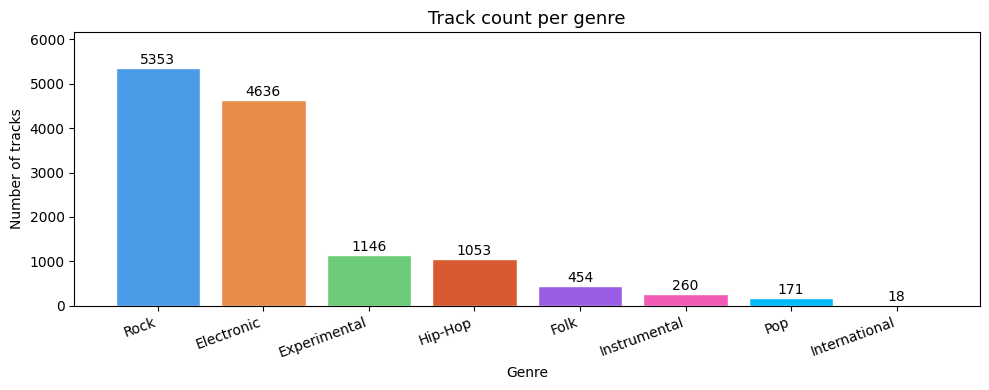

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))

counts = y.value_counts()
colors = ['#4C9BE8', '#E88C4C', '#6BCB77', '#D85A30',
          '#9B5DE5', '#F15BB5', '#00BBF9', '#FEE440']

bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha='center', va='bottom', fontsize=10)

ax.set_title('Track count per genre', fontsize=13)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of tracks')
ax.set_ylim(0, counts.max() * 1.15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('genre_distribution.png', dpi=150)
plt.show()

##### As we can see, the dataset is highly imbalanced. Rock accounts for 41% of all tracks, Electronic for 36%, and International for only 18 tracks (0.1%). This means that accuracy, as a metric, is somewhat misleading—the model might simply be guessing between Rock and Electronic and achieving a high score.

### Train/Validation/Test Splits

In [7]:
# Splitting data
split_info = tracks.loc[common_ids, ('set', 'split')]

X_train = X[split_info == 'training']
y_train = y[split_info == 'training']

X_val = X[split_info == 'validation']
y_val = y[split_info == 'validation']

X_test = X[split_info == 'test']
y_test = y[split_info == 'test']

print(f"Train: {X_train.shape} \nValidation: {X_val.shape} \nTest: {X_test.shape}")

Train: (10391, 518) 
Validation: (1358, 518) 
Test: (1342, 518)


##### The statistics for the features reveal significant differences in scale across all 518 features. For example, the zcr kurtosis index has a maximum value of 5,441, whereas the standard deviation of tonnetz is only 0.32. Without normalization, the Euclidean distance would be dominated by features with high values, effectively ignoring the rest. This necessitates the use of StandardScaler, which transforms each feature into a value with a mean of zero and a variance of one, ensuring that all features contribute equally to the distance calculation.

In [8]:
# Scaling the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)


X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### Construction of the Random Matrix

In [9]:
# Creating a function for Achlioptas matrix 
def achlioptas_matrix(d, l):
    vals = [np.sqrt(3), 0, -np.sqrt(3)]
    probs = [1/6, 2/3, 1/6]
    return np.random.choice(vals, size=(d, l), p=probs)

In [10]:
l = 10  
n = 15   
d = X_train_scaled.shape[1] 
    
lsh_tables = []
r_matrices = []

for i in range(n):
    R = achlioptas_matrix(d, l)
    r_matrices.append(R)
    table = {} 
    
    projections = np.dot(X_train_scaled, R)
    hashes = (projections >= 0).astype(int)
    
    for idx, h in enumerate(hashes):
        hash_tuple = tuple(h)
        if hash_tuple not in table:
            table[hash_tuple] = []
        table[hash_tuple].append(idx) 
    
    lsh_tables.append(table)

In [11]:
def predict_genre(x, k, lsh_tables, r_matrices, X_train_scaled, y_train, metric='euclidean'):
    candidate_indices = set()
    for i in range(len(lsh_tables)):
        projection = np.dot(x, r_matrices[i])
        h = tuple((projection >= 0).astype(int))
        if h in lsh_tables[i]:
            candidate_indices.update(lsh_tables[i][h])

    if not candidate_indices:
        from collections import Counter
        return Counter(y_train).most_common(1)[0][0]

    candidate_list = list(candidate_indices)
    X_candidates = X_train_scaled[candidate_list]  # Matrix of candidates

    # Counting the similarity regarding the metrics 

    if metric == 'euclidean':
        # Euclidean distance
        distances = np.linalg.norm(X_candidates - x, axis=1)
        # Sorting in ascending order 
        sorted_indices = np.argsort(distances)[:k]

    elif metric == 'cosine':
        # Cosine similarity 
        norm_x = np.linalg.norm(x)
        norms_candidates = np.linalg.norm(X_candidates, axis=1)
        denominators = norm_x * norms_candidates
        denominators[denominators == 0] = 1e-10
        dot_products = X_candidates @ x

        similarities = dot_products / denominators
        # Sorting in descending order
        sorted_indices = np.argsort(similarities)[::-1][:k]

    # Majority vote 
    top_k_indices = [candidate_list[i] for i in sorted_indices]
    neighbor_genres = y_train.iloc[top_k_indices].values

    vote_counts = {}
    for genre in neighbor_genres:
        vote_counts[genre] = vote_counts.get(genre, 0) + 1
    
    most_common_genre = max(vote_counts, key=vote_counts.get)

    return most_common_genre

In [12]:
k = 10
predictions = []

for track in X_val_scaled:
    res = predict_genre(track, k, lsh_tables, r_matrices, X_train_scaled, y_train)
    predictions.append(res)

# Euclidean distance
preds_euc = []
for track in X_val_scaled:
    res = predict_genre(track, k, lsh_tables, r_matrices,
                        X_train_scaled, y_train, metric='euclidean')
    preds_euc.append(res)

acc_euc = np.mean(np.array(preds_euc) == y_val.values)
print(f"Euclidean distance:   {acc_euc * 100:.2f}%")

# Cosine similarity
preds_cos = []
for track in X_val_scaled:
    res = predict_genre(track, k, lsh_tables, r_matrices,
                        X_train_scaled, y_train, metric='cosine')
    preds_cos.append(res)

acc_cos = np.mean(np.array(preds_cos) == y_val.values)
print(f"Cosine similarity:  {acc_cos * 100:.2f}%")

Euclidean distance:   67.45%
Cosine similarity:  70.99%


##### Cosine similarity measures the angle between two feature vectors, ignoring their magnitude. This is well-suited for audio features, where the shape of the feature profile matters more than the absolute values. Euclidean distance, on the other hand, is sensitive to the overall magnitude of the vectors. The observed difference between the two metrics is small (approximately 38 tracks out of 1,495) — this is partly because StandardScaler has already reduced magnitude differences, making the two metrics more similar in practice.